# U-Net Semantic Segmentation

In [1]:
from IPython import display
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchinfo import summary
import torchvision.datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from PIL import Image
import numpy as np
from tqdm.notebook import tqdm

### Key Features of U-Net:

1. **Architecture**: U-Net follows an **encoder-decoder** structure.
   - **Encoder (Contracting Path)**: The encoder is a series of convolutional layers followed by max-pooling layers. This part of the network captures abstract features from the image while progressively reducing the spatial dimensions. It acts as a feature extractor.
   - **Bottleneck**: The bottleneck is the narrowest part of the network, where the image’s feature representation is at its most compressed. Here, the model learns the most abstract features.
   - **Decoder (Expansive Path)**: The decoder progressively increases the image size using upsampling and transposed convolutions, restoring spatial dimensions. It helps reconstruct the segmentation map.

2. **Skip Connections:** One of the most notable features of U-Net is the use of skip connections between the encoder and decoder layers. These skip connections allow the network to pass feature maps from the encoder directly to the corresponding layers in the decoder. This helps the model retain fine-grained spatial information that could be lost during downsampling in the encoder.

3. **Output:** The final layer of the U-Net model outputs a segmentation map, where each pixel is classified into one of the predefined categories (for binary or multi-class segmentation). The model's goal is to predict which class each pixel in the image belongs to, such as distinguishing a tumor from normal tissue in medical scans.

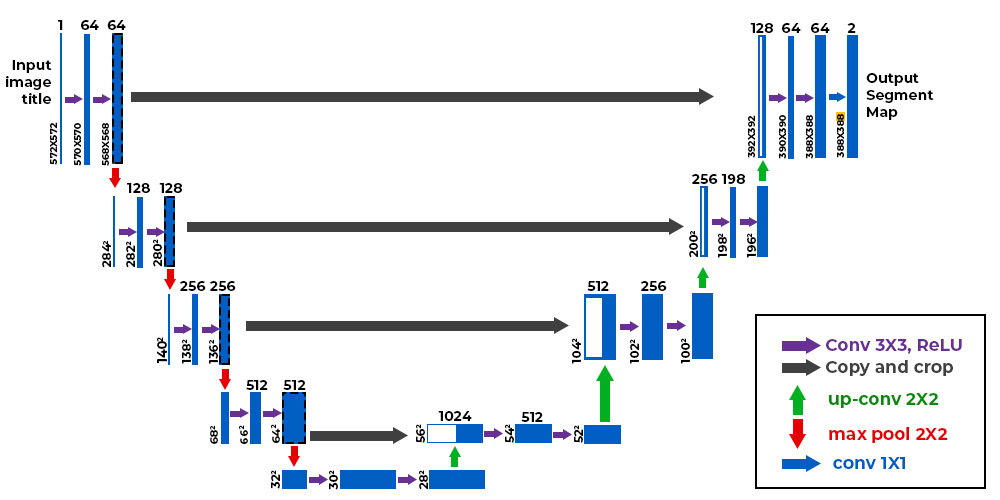

In [2]:
# Following image is understanding only
display.Image("images/unet.jpg")

## Setup : Load the Dataset

The **Oxford Pets Dataset** (also known as the Oxford IIIT Pets Dataset) is a popular dataset used for image classification and segmentation tasks, particularly in the context of animal and pet identification. The dataset contains 7,349 images of 37 different breeds of cats and dogs. Each image is annotated with a class label indicating the breed of the animal. The images have varying sizes, but most images are of high resolution (e.g., around 300x300 pixels or more). Segmentation masks are provided to indicate the pixel-level annotation of the pet (i.e., separating the pet from the background). This makes the dataset useful for tasks like semantic segmentation.

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Running on a GPU")
else:
    device = torch.device("cpu")
    print("Running on a CPU")

Running on a GPU


In [4]:
class Rescale(object):
    """Rescale the image in a sample to a given size.

    Args:
        output_size (tuple or int): Desired output size. If tuple, output is
            matched to output_size. If int, smaller of image edges is matched
            to output_size keeping aspect ratio the same.
    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        self.output_size = output_size

    def __call__(self, sample):
        image = sample
        h, w = image.size
        if h > w:
            new_h, new_w = self.output_size * h / w, self.output_size
        else:
            new_h, new_w = self.output_size, self.output_size * w / h
        new_h, new_w = int(new_h), int(new_w)
        img = TF.resize(image, (new_w, new_h))
        return img

The images in the Oxford Pets dataset come in different sizes. Therefore, we will adapt a transformation scheme that scales and crops each image down to a 128 by 128 images

In [5]:
num_classes = 3 # as specified above, there are 3 classes for each pixel
img_dim = 128
trainset = torchvision.datasets.OxfordIIITPet(root="./", download=True, target_types='segmentation',
                                              transform=transforms.Compose([
                                                            Rescale(img_dim),
                                                            transforms.CenterCrop(img_dim),
                                                            transforms.ToTensor()]),
                                              target_transform=transforms.Compose([
                                                            Rescale(img_dim),
                                                            transforms.CenterCrop(img_dim),
                                                            transforms.Lambda(lambda x: torch.from_numpy(np.array(x) - 1).long())]))
testset = torchvision.datasets.OxfordIIITPet(root="./", download=True, target_types='segmentation', split='test',
                                             transform=transforms.Compose([
                                                            Rescale(img_dim),
                                                            transforms.CenterCrop(img_dim),
                                                            transforms.ToTensor()]),
                                             target_transform=transforms.Compose([
                                                            Rescale(img_dim),
                                                            transforms.CenterCrop(img_dim),
                                                            transforms.Lambda(lambda x: torch.from_numpy(np.array(x) - 1).long())]))

Let's look at 4 random samples from this dataset.

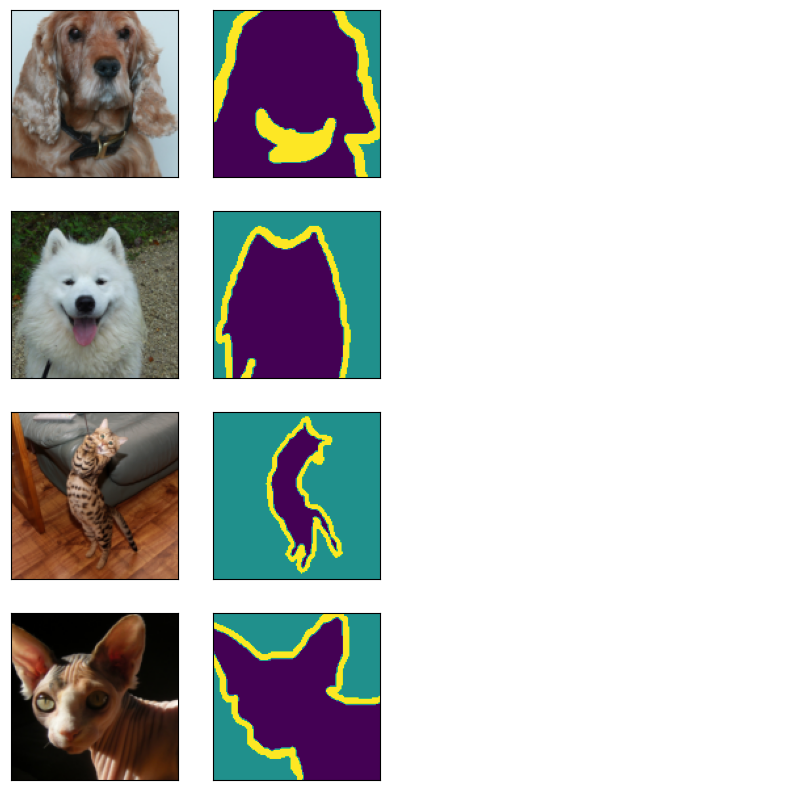

In [6]:
num_samples = 4
img_grid = gs.GridSpec(num_samples, 4, width_ratios=[1, 1, 1, 1])
fig = plt.figure(figsize=(10, 10))
plt.axis('off')

for idx, i in enumerate(np.random.choice(len(trainset), num_samples)):
    image, label = trainset[i]
    plt.subplot(img_grid[idx, 0]).imshow(image.permute(1, 2, 0))
    plt.subplot(img_grid[idx, 1]).imshow(label.squeeze())
for ax in fig.get_axes():
    ax.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
plt.show()

## Defining the Model

To make the process of creating a giant neural network like this easier, let's break down the network into smaller blocks and chain those afterwards using pooling and transposed convolution layers.

In [7]:
class UNetBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        '''
        Here is the expected architecture for a single U-Net Block
        1. Convolutional layer with kernel_size = 3 and padding = (1, 1)
        2. ReLU activation
        3. Batchnorm layer
        4. Convolutional layer with kernel_size = 3 and padding = (1, 1)
        5. ReLU activation
        6. Batchnorm layer

        The kernel size and padding are chosen to preserve the spatial dimensions
        across the inputs and outputs to this block. Both convolutional layers
        have the same number of output channels
        '''
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=input_channels,
                               out_channels=output_channels,
                               kernel_size=3,
                               padding=(1, 1))
        self.bn1 = nn.BatchNorm2d(num_features=output_channels)
        self.conv2 = nn.Conv2d(in_channels=output_channels,
                               out_channels=output_channels,
                               kernel_size=3,
                               padding=(1, 1))
        self.bn2 = nn.BatchNorm2d(num_features=output_channels)

    def forward(self, x):
        # TODO: perform a forward pass with the layers above
        out = self.bn1(F.relu(self.conv1(x)))
        out = self.bn2(F.relu(self.conv2(out)))
        return out

In [8]:
class UNet(nn.Module):
    def __init__(self, num_classes):
        '''
        1. U-Net block with 3 input channels and 32 output channels
        2. Max pooling
        3. U-Net block with 32 input channels and 64 output channels
        4. Max pooling
        5. U-Net block with 64 input channels and 128 output channels
        6. Max pooling
        7. U-Net block with 128 input channels and 256 output channels
        8. Max pooling
        9. U-Net block with 256 output channels and 512 output channels
        10. Transpose convolution from 512 input channels to 256 output channels
        11. U-Net block with 512 input channels and 256 output channels
        12. Transpose convolution from 256 input channels to 128 output channels
        13. U-Net block with 256 input channels and 128 output channels
        14. Transpose convolution from 128 input channels to 64 output channels
        15. U-Net block with 128 input channels to 64 output channels
        16. Transpose convolution from 64 input channels to 32 output channels
        17. A single convolutional layer from 32 input channels to `num_classes` output channels

        All transpose convolutions should use a kernel_size of 3, stride of 2,
        padding of 1 and output_padding of 1. This will ensure that the spatial
        dimensions of the intermediate activations are doubled after each upsampling
        operation.
        '''
        super().__init__()
        self.num_classes = num_classes

        self.block1 = UNetBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.block2 = UNetBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.block3 = UNetBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.block4 = UNetBlock(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        self.block5 = UNetBlock(256, 512)

        self.upconv1 = nn.ConvTranspose2d(512, 256, 3, 2, 1, 1)
        self.block6 = UNetBlock(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, 3, 2, 1, 1)
        self.block7 = UNetBlock(256, 128)

        self.upconv3 = nn.ConvTranspose2d(128, 64, 3, 2, 1, 1)
        self.block8 = UNetBlock(128, 64)

        self.upconv4 = nn.ConvTranspose2d(64, 32, 3, 2, 1, 1)
        self.block9 = UNetBlock(64, 32)

        self.block10 = nn.Conv2d(32, self.num_classes, 3, 1, 1)

    def forward(self, x):
        '''
        Forward pass of the U-Net model, given an input image x.
        In the comments to the right, the first column indicates the number of
        channels in the output of the corresponding layer while the second and
        third highlight the spatial dimensions.
        '''
        out1 = self.block1(x)                   # 32,  1,    1

        out2 = self.pool1(out1)                 # 32,  1/2,  1/2
        out2 = self.block2(out2)                # 64,  1/2,  1/2

        out3 = self.pool2(out2)                 # 64,  1/4,  1/4
        out3 = self.block3(out3)                # 128, 1/4,  1/4

        out4 = self.pool3(out3)                 # 128, 1/8,  1/8
        out4 = self.block4(out4)                # 256, 1/8,  1/8

        out5 = self.pool4(out4)                 # 256, 1/16, 1/16
        out5 = self.block5(out5)                # 512, 1/16, 1/16

        out6 = self.upconv1(out5)               # 256, 1/8,  1/8
        out6 = torch.cat([out4, out6], dim=1)   # 512, 1/8,  1/8
        out6 = self.block6(out6)                # 256, 1/8,  1/8

        out7 = self.upconv2(out6)               # 128, 1/4,  1/4
        out7 = torch.cat([out3, out7], dim=1)   # 256, 1/4,  1/4
        out7 = self.block7(out7)                # 128, 1/4,  1/4

        out8 = self.upconv3(out7)               # 64,  1/2,  1/2
        out8 = torch.cat([out2, out8], dim=1)   # 128, 1/2,  1/2
        out8 = self.block8(out8)                # 64,  1/2,  1/2

        out9 = self.upconv4(out8)               # 32,  1,    1
        out9 = torch.cat([out1, out9], dim=1)   # 64,  1,    1
        out9 = self.block9(out9)                # 32,  1,    1

        out = self.block10(out9)                # n_c, 1,    1
        return out

In [9]:
u_net = UNet(num_classes).to(device)
summary(u_net, input_size=(16, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [16, 3, 64, 64]           --
├─UNetBlock: 1-1                         [16, 32, 64, 64]          --
│    └─Conv2d: 2-1                       [16, 32, 64, 64]          896
│    └─BatchNorm2d: 2-2                  [16, 32, 64, 64]          64
│    └─Conv2d: 2-3                       [16, 32, 64, 64]          9,248
│    └─BatchNorm2d: 2-4                  [16, 32, 64, 64]          64
├─MaxPool2d: 1-2                         [16, 32, 32, 32]          --
├─UNetBlock: 1-3                         [16, 64, 32, 32]          --
│    └─Conv2d: 2-5                       [16, 64, 32, 32]          18,496
│    └─BatchNorm2d: 2-6                  [16, 64, 32, 32]          128
│    └─Conv2d: 2-7                       [16, 64, 32, 32]          36,928
│    └─BatchNorm2d: 2-8                  [16, 64, 32, 32]          128
├─MaxPool2d: 1-4                         [16, 64, 16, 16]          --
├

## Training

In [10]:
def iou(outputs, labels):
    '''
    Compute the IOU metric for each sample in a batch

    outputs: batch of outputs from a UNet with shape (batch_size, num_classes, height, width)
    labels: batch of labels with shape (batch_size, height, width)
    returns: mean iou over the entire batch
    '''
    SMOOTH = 1e-6
    outputs = torch.argmax(outputs, dim=1).squeeze(1)
    intersection = (outputs & labels).float().sum((-1, -2))
    union = (outputs | labels).float().sum((-1, -2))
    iou = (intersection + SMOOTH) / (union + SMOOTH)
    return iou.mean()

def mean_iou(dataset, model):
    '''
    Compute the mean IOU for a given model over the given dataset
    '''
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    set_iou = []
    with torch.no_grad():
        model.eval()
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).squeeze()
            predictions = model(images)
            set_iou.append(iou(predictions, labels))

    mean_iou = sum(set_iou) / len(set_iou)
    return mean_iou.item()

In [11]:
def training_loop(model, num_epochs, batch_size, trainset, optimizer, scheduler):
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    train_loss = []
    for epoch in range(1, num_epochs + 1):
        batches = tqdm(train_loader, initial=1)
        model.train()
        running_loss = 0
        for images, labels in batches:
            images = images.to(device)
            labels = labels.to(device).squeeze()
            predictions = model(images)
            optimizer.zero_grad()
            loss = F.cross_entropy(predictions, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        if scheduler:
            scheduler.step()
        epoch_iou = mean_iou(trainset, model)
        train_loss.append(running_loss / len(train_loader))
        print("Epoch: {0:02d} | Training Loss: {1:.5f} | IOU: {2:.5f}".format(epoch, train_loss[-1], epoch_iou))
    return train_loss

In [12]:
num_epochs = 15
batch_size = 128
learning_rate = 1e-3

model = UNet(num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

train_loss = training_loop(model, num_epochs, batch_size, trainset, optimizer, scheduler=scheduler)

  3%|3         | 1/29 [00:00<?, ?it/s]

Epoch: 01 | Training Loss: 0.85692 | IOU: 0.16916


  3%|3         | 1/29 [00:00<?, ?it/s]

Epoch: 02 | Training Loss: 0.64076 | IOU: 0.49504


  3%|3         | 1/29 [00:00<?, ?it/s]

...

Epoch: 13 | Training Loss: 0.27087 | IOU: 0.71893


  3%|3         | 1/29 [00:00<?, ?it/s]

Epoch: 14 | Training Loss: 0.26269 | IOU: 0.72519


  3%|3         | 1/29 [00:00<?, ?it/s]

Epoch: 15 | Training Loss: 0.25701 | IOU: 0.72982


# Visualizing the results

Let's consider the performance of the model on the test set by computing its IOU. 

In [13]:
mean_iou(testset, model)

0.6803076267242432

Visualize the model's predictions on random samples from the training set. In the plot below, the left column is the image, the middle column is its label and the right column shows the model's prediction.

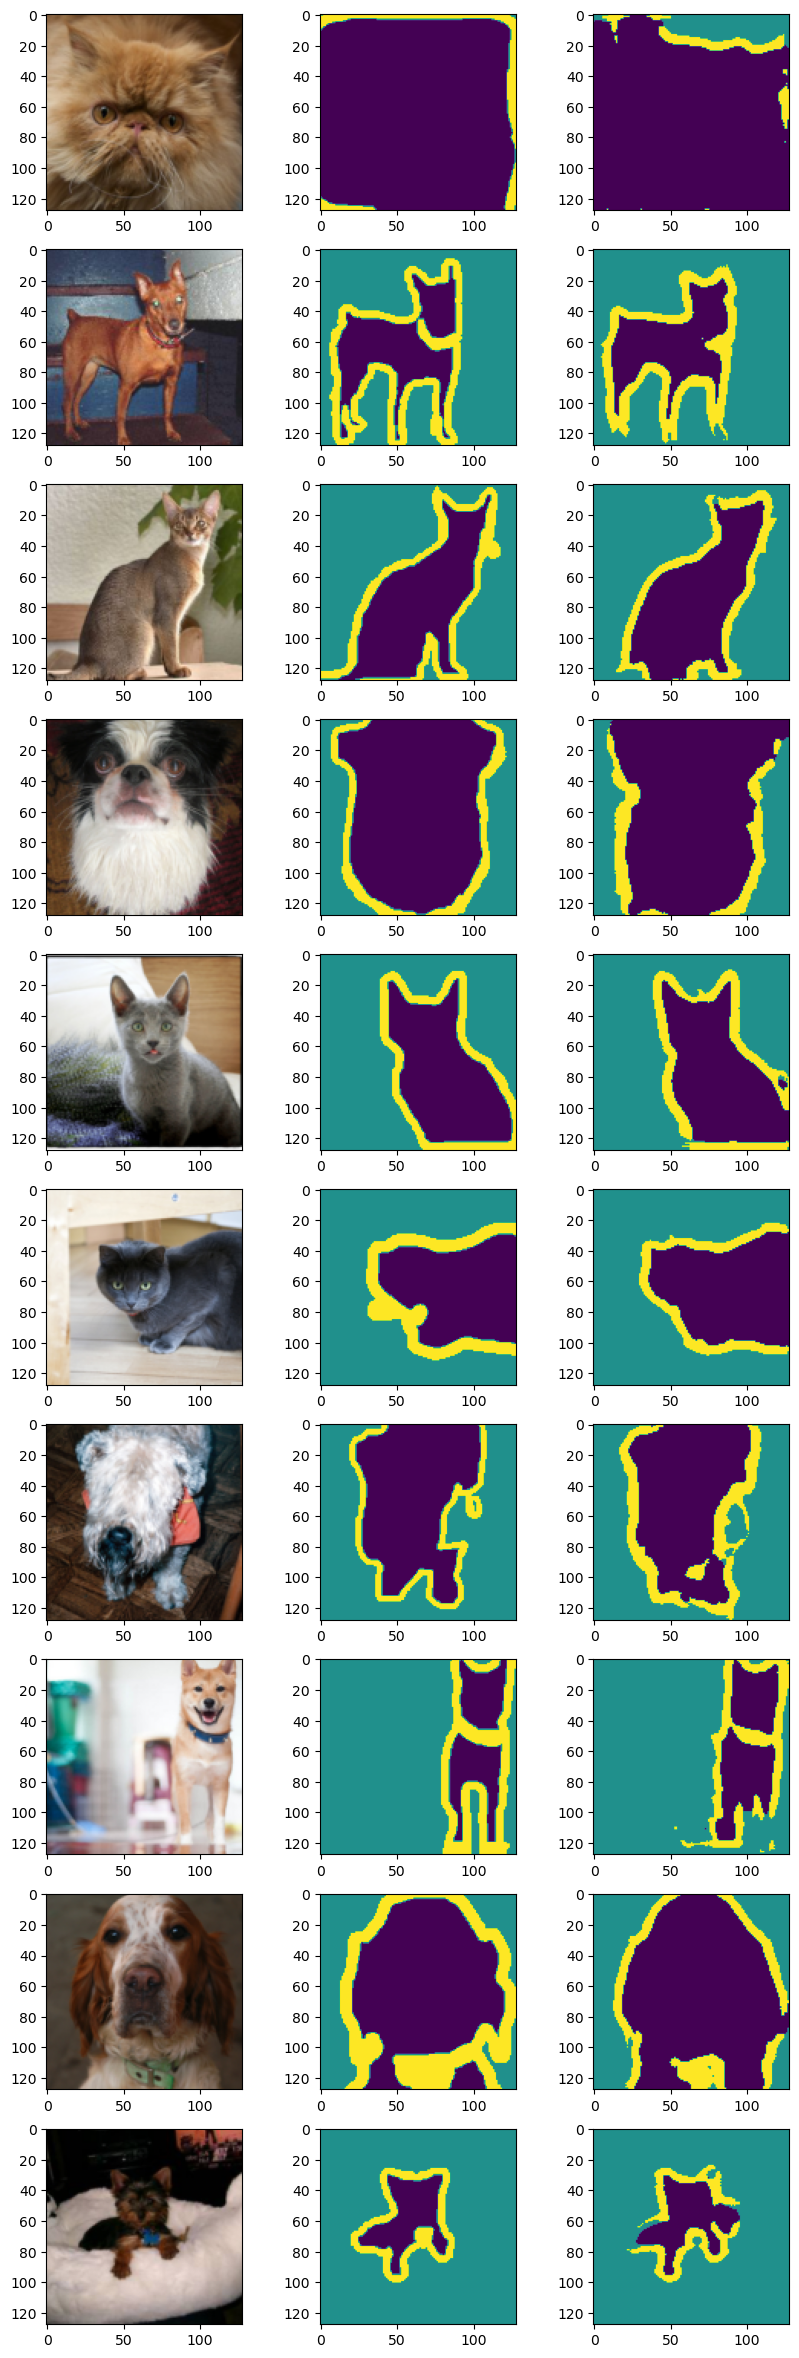

In [14]:
num_samples = 10
img_grid = gs.GridSpec(num_samples, 3, width_ratios=[1, 1, 1], wspace=0.2, hspace=0.2)
fig = plt.figure(figsize=(10, 30))

for idx, i in enumerate(np.random.choice(len(trainset), num_samples)):
    image, label = trainset[i]
    image = image.to(device)
    pred = model(image.unsqueeze(dim=0)).squeeze()
    pred = torch.argmax(pred, dim=0).cpu()
    image = image.cpu()
    plt.subplot(img_grid[idx, 0]).imshow(image.permute(1, 2, 0))
    plt.subplot(img_grid[idx, 1]).imshow(label.squeeze())
    plt.subplot(img_grid[idx, 2]).imshow(pred.squeeze())

Now, visualize the model's predictions on random samples from the test set. As before, the left column is the image, the middle column is its label and the right column shows the model's prediction.

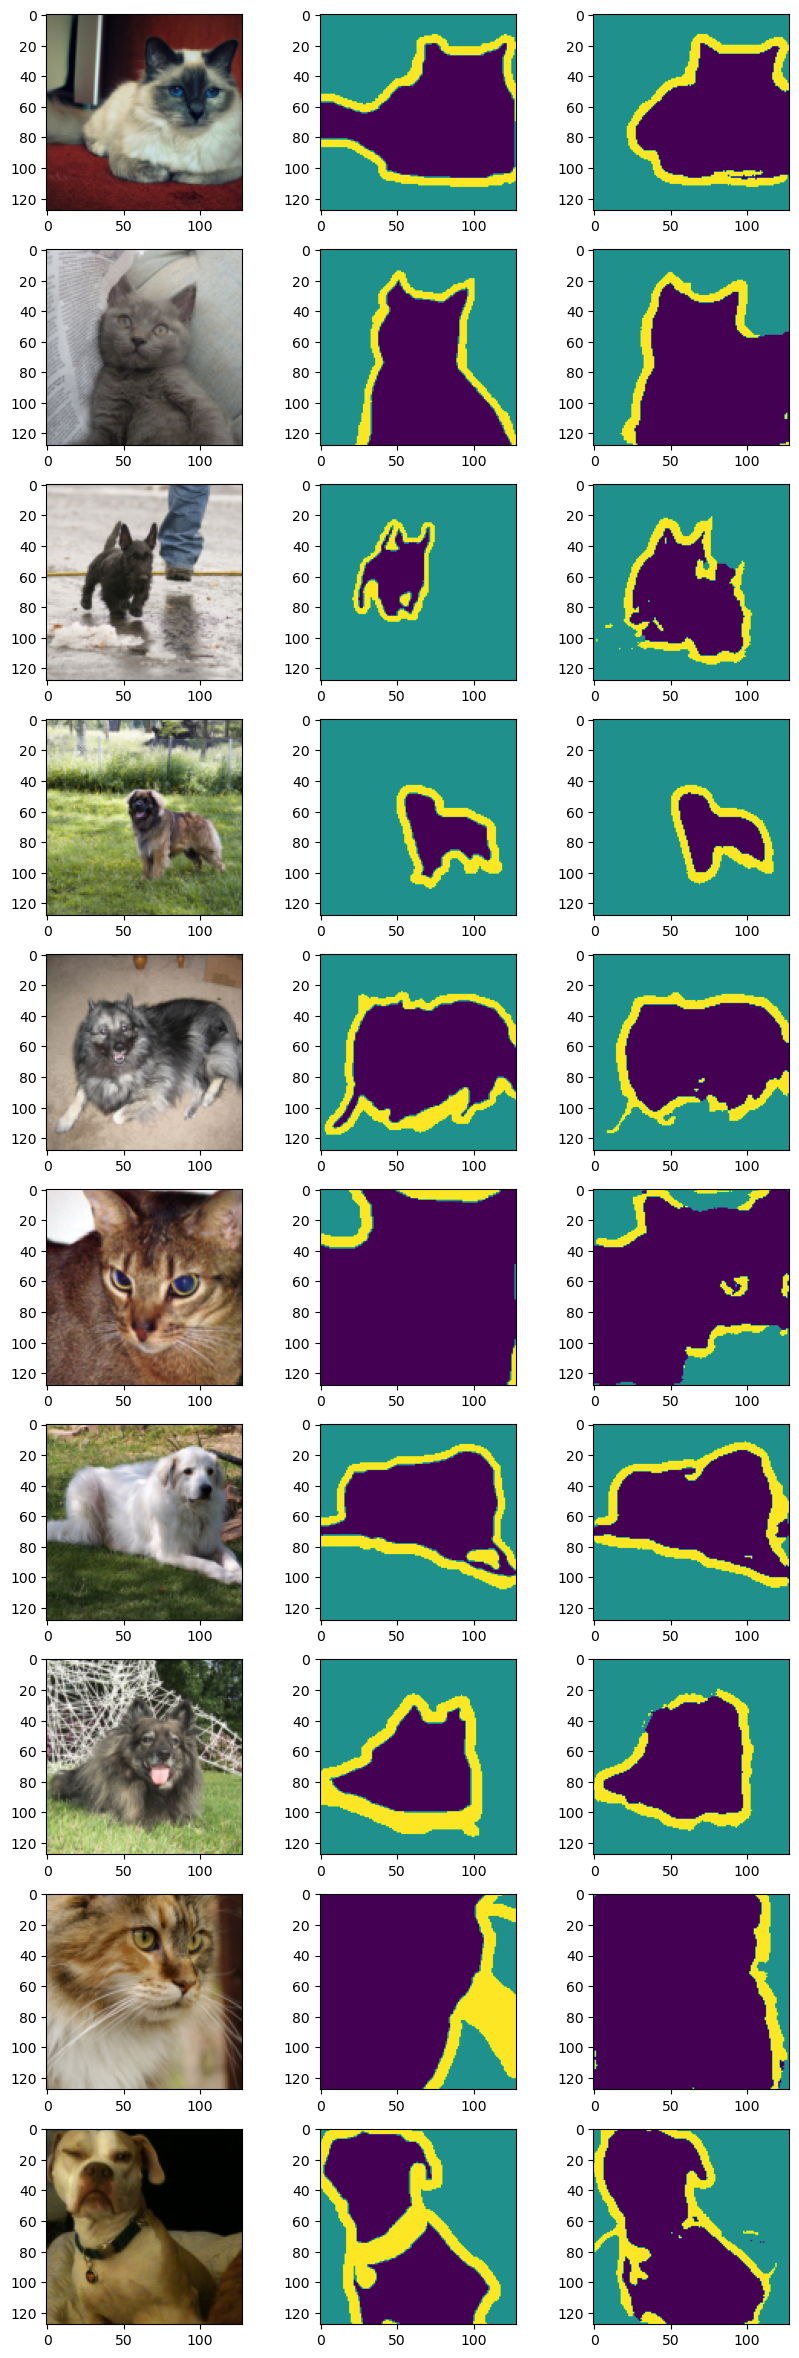

In [15]:
num_samples = 10
img_grid = gs.GridSpec(num_samples, 3, width_ratios=[1, 1, 1], wspace=0.2, hspace=0.2)
fig = plt.figure(figsize=(10, 30))

for idx, i in enumerate(np.random.choice(len(testset), num_samples)):
    image, label = testset[i]
    image = image.to(device)
    pred = model(image.unsqueeze(dim=0)).squeeze()
    pred = torch.argmax(pred, dim=0).cpu()
    image = image.cpu()
    plt.subplot(img_grid[idx, 0]).imshow(image.permute(1, 2, 0))
    plt.subplot(img_grid[idx, 1]).imshow(label.squeeze())
    plt.subplot(img_grid[idx, 2]).imshow(pred.squeeze())